<a href="https://colab.research.google.com/github/rbnascimentoo/desafio-pratico-analise-financeira-com-python/blob/main/Desafio_pr%C3%A1tico_An%C3%A1lise_Financeira_com_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Desafio prático: Análise Financeira com Python

In [94]:
import os
import csv
import random
from datetime import datetime, timedelta
import json

import matplotlib.pyplot as plt
import numpy as np

In [95]:
def gerar_dados(nome_arquivo='transacoes.csv'):
  if os.path.exists(nome_arquivo):
    print(f"Arquivo '{nome_arquivo}' já existe.")
    return

  print("Gerando arquivo...")

  transacoes = []

  data_inicial = datetime(2026, 1, 1)

  categorias_opcoes = ["salario", "compra", "transferencia", "investimento", "conta", "alimentacao"]

  # descrição dinâmica
  descricoes = {
      "salario": ["Salário mensal", "Adiantamento", "Bônus"],
      "compra": ["Supermercado", "Eletrônicos", "Roupas"],
      "transferencia": ["Pix recebido", "Transferência enviada"],
      "investimento": ["Compra cota VISC11", "Rendimento HGLG11", "Venda KNCR11", "Compra XPML11", "Compra cota CPTS11"],
      "conta": ["Conta de Luz", "Internet", "Condomínio"],
      "alimentacao": ["Restaurante", "iFood", "Padaria"]
  }

  for i in range(26):
    data_transacao = data_inicial + timedelta(days=random.randint(0, 100)) # 3 meses
    categoria = random.choice(categorias_opcoes)
    tipo = "credito" if categoria in ["salario"] else random.choice(["credito", "debito"])
    descricao = random.choice(descricoes[categoria])

    if categoria == "salario":
        valor = round(random.uniform(3500, 8000), 2)
    else:
        valor = round(random.uniform(20, 1500), 2)

    transacoes.append({
          "data": data_transacao.strftime("%Y-%m-%d"),
          "cliente_id": f"CLI{random.randint(1, 20):03d}",
          "tipo": tipo,
          "valor": valor,
          "descricao": descricao,
          "categoria": categoria
    })

  # Gera itens com acima de R$10000
  transacoes.extend([
        {"data": "2026-02-15", "cliente_id": "CLI001", "tipo": "credito", "valor": 15000.00, "descricao": "Venda de veículo", "categoria": "transferencia"},
        {"data": "2026-03-20", "cliente_id": "CLI002", "tipo": "debito", "valor": 12500.00, "descricao": "Pagamento de reforma", "categoria": "servicos"},
        {"data": "2026-03-10", "cliente_id": "CLI015", "tipo": "debito", "valor": 35000.00, "descricao": "Aporte maciço KNCR11", "categoria": "investimento"},
        {"data": "2026-04-02", "cliente_id": "CLI005", "tipo": "credito", "valor": 18500.00, "descricao": "Liquidação FII HGLG11", "categoria": "investimento"}
  ])
  # Gera itens inválidos
  transacoes_invalidas = [
      {"data": "2026-01-10", "cliente_id": "CLI021", "tipo": "debito", "valor": -50.00, "descricao": "Erro valor negativo", "categoria": "erro"},
      {"data": "2026-02-28", "cliente_id": "", "tipo": "credito", "valor": 500.00, "descricao": "Erro sem cliente", "categoria": "erro"},
      {"data": "20-03-2026", "cliente_id": "CLI022", "tipo": "debito", "valor": 100.00, "descricao": "Erro formato data", "categoria": "erro"},
      {"data": "2026-04-05", "cliente_id": "CLI023", "tipo": "pix", "valor": 200.00, "descricao": "Erro tipo transação", "categoria": "erro"},
      {"data": "2026-04-10", "cliente_id": "CLI024", "tipo": "debito", "valor": "abc", "descricao": "Erro valor string", "categoria": "erro"},
      {"data": "2026-01-25", "cliente_id": "CLI025", "tipo": "debito", "valor": 0.00, "descricao": "Erro valor zero", "categoria": "erro"},
      {"data": "2026-02-10", "cliente_id": "CLI026", "tipo": "TED", "valor": 150.00, "descricao": "Erro tipo transacao 2", "categoria": "erro"},
      {"data": "25/02/2026", "cliente_id": "CLI027", "tipo": "credito", "valor": 300.00, "descricao": "Erro data padrao BR", "categoria": "erro"},
      {"id_corrompido": "ABC", "data": "2026-03-05", "cliente_id": "CLI028", "tipo": "debito", "valor": 80.00, "descricao": "Erro ID string", "categoria": "erro"},
      {"id_corrompido": "", "data": "2026-03-12", "cliente_id": "CLI029", "tipo": "credito", "valor": 120.00, "descricao": "Erro ID vazio", "categoria": "erro"}
  ]
  transacoes.extend(transacoes_invalidas)

  random.shuffle(transacoes) # Mistura válidos e inválidos

  with open(nome_arquivo, mode='w', encoding='utf-8', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=["id", "data", "cliente_id", "tipo", "valor", "descricao", "categoria"])
    writer.writeheader()

    for index, t in enumerate(transacoes, start=1):
        if "id_corrompido" in t:
            t["id"] = t.pop("id_corrompido")
        else:
            t["id"] = index
        writer.writerow(t)

  print(f"✓ Arquivo '{nome_arquivo}' criado com {len(transacoes)} registros (embaralhados).")

In [97]:
gerar_dados()

Gerando arquivo...
✓ Arquivo 'transacoes.csv' criado com 40 registros (embaralhados).


In [101]:
def validar_transacao(linha):
  try:
    id_transacao = int(linha.get('id', ''))
  except ValueError:
    raise ValueError("ID deve ser um número inteiro.")

  cliente_id = linha.get('cliente_id', '').strip()
  if not cliente_id:
      raise ValueError("Cliente ID vazio")

  try:
      data_obj = datetime.strptime(linha.get('data', '').strip(), '%Y-%m-%d')
  except ValueError:
      raise ValueError("Formato de data inválido")

  tipo = linha.get('tipo', '').strip().lower()
  if tipo not in ['credito', 'debito']:
      raise ValueError("Tipo de transação desconhecido")

  try:
      valor = float(linha.get('valor', ''))
      if valor <= 0:
          raise ValueError("Valor negativo ou zero")
  except ValueError:
      raise ValueError("Valor não numérico")

  return {
        'id': id_transacao,
        'data_obj': data_obj,
        'data_str': data_obj.strftime('%Y-%m'),
        'cliente_id': cliente_id,
        'tipo': tipo,
        'valor': valor,
        'categoria': linha.get('categoria', '')
    }


In [102]:
def ler_transacoes(nome_arquivo='transacoes.csv'):
  transacoes_limpas = []
  total_lidas = 0
  total_invalidas = 0

  try:
    with open(nome_arquivo, mode='r', encoding='utf-8') as f:
      leitor = csv.DictReader(f)
      for linha in leitor:
        total_lidas += 1
        try:
          transacao_valida = validar_transacao(linha)
          transacoes_limpas.append(transacao_valida)
        except ValueError:
          total_invalidas += 1
  except FileNotFoundError:
    print(f"Erro: O arquivo '{nome_arquivo}' não foi encontrado no sistema.")
    return [], 0, 0

  print("--- Resumo da Leitura e Limpeza ---")
  print(f"Total de linhas lidas: {total_lidas}")
  print(f"Linhas válidas aprovadas: {len(transacoes_limpas)}")
  print(f"Linhas inválidas descartadas: {total_invalidas}\n")

  return transacoes_limpas, len(transacoes_limpas), total_invalidas

In [103]:
ler_transacoes()

--- Resumo da Leitura e Limpeza ---
Total de linhas lidas: 40
Linhas válidas aprovadas: 30
Linhas inválidas descartadas: 10



([{'id': 1,
   'data_obj': datetime.datetime(2026, 2, 6, 0, 0),
   'data_str': '2026-02',
   'cliente_id': 'CLI014',
   'tipo': 'debito',
   'valor': 1282.9,
   'categoria': 'transferencia'},
  {'id': 3,
   'data_obj': datetime.datetime(2026, 2, 10, 0, 0),
   'data_str': '2026-02',
   'cliente_id': 'CLI012',
   'tipo': 'credito',
   'valor': 4279.3,
   'categoria': 'salario'},
  {'id': 4,
   'data_obj': datetime.datetime(2026, 2, 2, 0, 0),
   'data_str': '2026-02',
   'cliente_id': 'CLI019',
   'tipo': 'debito',
   'valor': 340.98,
   'categoria': 'alimentacao'},
  {'id': 5,
   'data_obj': datetime.datetime(2026, 2, 2, 0, 0),
   'data_str': '2026-02',
   'cliente_id': 'CLI001',
   'tipo': 'debito',
   'valor': 68.48,
   'categoria': 'conta'},
  {'id': 6,
   'data_obj': datetime.datetime(2026, 1, 9, 0, 0),
   'data_str': '2026-01',
   'cliente_id': 'CLI007',
   'tipo': 'credito',
   'valor': 1448.43,
   'categoria': 'conta'},
  {'id': 7,
   'data_obj': datetime.datetime(2026, 1, 13, 0, 

In [104]:
lista_final, validas, invalidas = ler_transacoes()

if lista_final:
    print("Primeiro registro válido aprovado:")
    print(lista_final[0])

--- Resumo da Leitura e Limpeza ---
Total de linhas lidas: 40
Linhas válidas aprovadas: 30
Linhas inválidas descartadas: 10

Primeiro registro válido aprovado:
{'id': 1, 'data_obj': datetime.datetime(2026, 2, 6, 0, 0), 'data_str': '2026-02', 'cliente_id': 'CLI014', 'tipo': 'debito', 'valor': 1282.9, 'categoria': 'transferencia'}


In [105]:
LIMITE_SUSPEITO = 10000.00

def gerar_relatorio(transacoes, total_validadas, total_invalidas):

  if not transacoes:
    print("Nenhuma transação para gerar relatório.")
    return None

  relatorio = {
    "gerado_em": datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    "total_transacoes_validas": total_validadas, # Corrected variable name
    "total_transacoes_invalidas": total_invalidas,
    "periodo_analisado": {},
    "resumo_mensal": {},
    "transacoes_suspeitas": []
  }

  datas_objetos = []

  for t in transacoes:
        mes_ano = t['data_str']
        valor = t['valor']
        datas_objetos.append(t['data_obj'])

        if valor > LIMITE_SUSPEITO:
            relatorio["transacoes_suspeitas"].append({
                "id": t['id'],
                "cliente_id": t['cliente_id'],
                "data": t['data_obj'].strftime('%Y-%m-%d'),
                "valor": valor,
                "categoria": t['categoria']
            })

        if mes_ano not in relatorio["resumo_mensal"]:
            relatorio["resumo_mensal"][mes_ano] = {
                "quantidade_transacoes": 0,
                "total_credito": 0.0,
                "total_debito": 0.0,
                "_valores_brutos": []
            }

        mes_ref = relatorio["resumo_mensal"][mes_ano]
        mes_ref["quantidade_transacoes"] += 1
        mes_ref["_valores_brutos"].append(valor)

        if t['tipo'] == 'credito':
            mes_ref["total_credito"] += valor
        elif t['tipo'] == 'debito':
            mes_ref["total_debito"] += valor

  for mes, dados in relatorio["resumo_mensal"].items():
      dados["saldo_mensal"] = round(dados["total_credito"] - dados["total_debito"], 2)

      lista_valores = dados["_valores_brutos"]
      dados["media_transacoes"] = round(sum(lista_valores) / len(lista_valores), 2)
      dados["maior_transacao"] = max(lista_valores)
      dados["menor_transacao"] = min(lista_valores)

      del dados["_valores_brutos"]

  data_inicio = min(datas_objetos)
  data_fim = max(datas_objetos)
  dias_corridos = (data_fim - data_inicio).days

  relatorio["periodo_analisado"] = {
      "data_inicio": data_inicio.strftime('%Y-%m-%d'),
      "data_fim": data_fim.strftime('%Y-%m-%d'),
      "dias_corridos": dias_corridos
  }

  return relatorio

In [106]:
lista_final, validas, invalidas = ler_transacoes()

gerar_relatorio(lista_final, validas, invalidas)

--- Resumo da Leitura e Limpeza ---
Total de linhas lidas: 40
Linhas válidas aprovadas: 30
Linhas inválidas descartadas: 10



{'gerado_em': '2026-06-16 02:03:52',
 'total_transacoes_validas': 30,
 'total_transacoes_invalidas': 10,
 'periodo_analisado': {'data_inicio': '2026-01-04',
  'data_fim': '2026-04-03',
  'dias_corridos': 89},
 'resumo_mensal': {'2026-02': {'quantidade_transacoes': 12,
   'total_credito': 20685.91,
   'total_debito': 7517.0599999999995,
   'saldo_mensal': 13168.85,
   'media_transacoes': 2350.25,
   'maior_transacao': 15000.0,
   'menor_transacao': 68.48},
  '2026-01': {'quantidade_transacoes': 6,
   'total_credito': 11193.599999999999,
   'total_debito': 1235.54,
   'saldo_mensal': 9958.06,
   'media_transacoes': 2071.52,
   'maior_transacao': 5453.23,
   'menor_transacao': 401.28},
  '2026-03': {'quantidade_transacoes': 10,
   'total_credito': 3326.58,
   'total_debito': 51461.62,
   'saldo_mensal': -48135.04,
   'media_transacoes': 5478.82,
   'maior_transacao': 35000.0,
   'menor_transacao': 61.19},
  '2026-04': {'quantidade_transacoes': 2,
   'total_credito': 18500.0,
   'total_deb

In [107]:
def salvar_json(relatorio, nome_arquivo='relatorio.json'):

    try:
        with open(nome_arquivo, 'w', encoding='utf-8') as f:
            json.dump(relatorio, f, indent=4, ensure_ascii=False)
        print(f"\n✓ Relatório exportado com sucesso para '{nome_arquivo}'!")
    except Exception as e:
        print(f"Erro ao salvar arquivo JSON: {e}")

In [108]:
def formatar_moeda(valor):
    # 1. Formata com 2 casas decimais e vírgula como separador de milhar
    valor_formatado = f"{valor:,.2f}"

    # 2. O Python coloca ponto no milhar e vírgula no decimal
    # Troca vírgula por um marcador temporário, depois ponto por vírgula, depois marcador por ponto.
    valor_formatado = valor_formatado.replace(",", "X").replace(".", ",").replace("X", ".")
    return f"R$ {valor_formatado}"

def exibir_relatorio(relatorio):
    if not relatorio:
        print("Relatório indisponível.")
        return

    print("=" * 30)
    print("      RELATÓRIO MENSAL      ")
    print("=" * 30)

    # Exibe o período analisado
    periodo = relatorio["periodo_analisado"]
    print(f"Período: {periodo['data_inicio']} a {periodo['data_fim']}")
    print(f"Dias corridos: {periodo['dias_corridos']}")
    print("-" * 30)

    # Exibe resumo mensal
    for mes in sorted(relatorio["resumo_mensal"].keys()):
        d = relatorio["resumo_mensal"][mes]
        print(f"Mês: {mes}")
        print(f"  Transações: {d['quantidade_transacoes']}")
        print(f"  Total crédito: {formatar_moeda(d['total_credito'])}")
        print(f"  Total débito:  {formatar_moeda(d['total_debito'])}")
        print(f"  Saldo:         {formatar_moeda(d['saldo_mensal'])}")
        print(f"  Média:         {formatar_moeda(d['media_transacoes'])}")
        print(f"  Maior valor:   {formatar_moeda(d['maior_transacao'])}")
        print(f"  Menor valor:   {formatar_moeda(d['menor_transacao'])}")
        print("-" * 20)

    # Exibe transações suspeitas
    print("\n===== TRANSAÇÕES SUSPEITAS =====")
    if not relatorio["transacoes_suspeitas"]:
        print("Nenhuma transação suspeita encontrada.")
    else:
        for t in relatorio["transacoes_suspeitas"]:
            print(f"ID: {t['id']} | Cliente: {t['cliente_id']} | Data: {t['data']} | Valor: {formatar_moeda(t['valor'])}")

In [110]:
def gerar_grafico(relatorio):
    meses = sorted(relatorio["resumo_mensal"].keys())
    creditos = [relatorio["resumo_mensal"][m]["total_credito"] for m in meses]
    debitos = [relatorio["resumo_mensal"][m]["total_debito"] for m in meses]

    x = np.arange(len(meses))  # Localização das barras
    largura = 0.35             # Largura das barras

    fig, ax = plt.subplots(figsize=(10, 6))

    # Criando as barras lado a lado
    rects1 = ax.bar(x - largura/2, creditos, largura, label='Crédito', color='green')
    rects2 = ax.bar(x + largura/2, debitos, largura, label='Débito', color='red')

    ax.set_ylabel('Valores (R$)')
    ax.set_title('Fluxo Financeiro Mensal: Crédito vs Débito')
    ax.set_xticks(x)
    ax.set_xticklabels(meses)
    ax.legend()

    # Salvando a imagem
    plt.savefig('grafico.png')
    print("\n Gráfico gerado e salvo como 'grafico.png'!")
    plt.show()

Iniciando processamento ClearBank...

Arquivo 'transacoes.csv' já existe.
--- Resumo da Leitura e Limpeza ---
Total de linhas lidas: 40
Linhas válidas aprovadas: 30
Linhas inválidas descartadas: 10

      RELATÓRIO MENSAL      
Período: 2026-01-04 a 2026-04-03
Dias corridos: 89
------------------------------
Mês: 2026-01
  Transações: 6
  Total crédito: R$ 11.193,60
  Total débito:  R$ 1.235,54
  Saldo:         R$ 9.958,06
  Média:         R$ 2.071,52
  Maior valor:   R$ 5.453,23
  Menor valor:   R$ 401,28
--------------------
Mês: 2026-02
  Transações: 12
  Total crédito: R$ 20.685,91
  Total débito:  R$ 7.517,06
  Saldo:         R$ 13.168,85
  Média:         R$ 2.350,25
  Maior valor:   R$ 15.000,00
  Menor valor:   R$ 68,48
--------------------
Mês: 2026-03
  Transações: 10
  Total crédito: R$ 3.326,58
  Total débito:  R$ 51.461,62
  Saldo:         R$ -48.135,04
  Média:         R$ 5.478,82
  Maior valor:   R$ 35.000,00
  Menor valor:   R$ 61,19
--------------------
Mês: 2026-04
  T

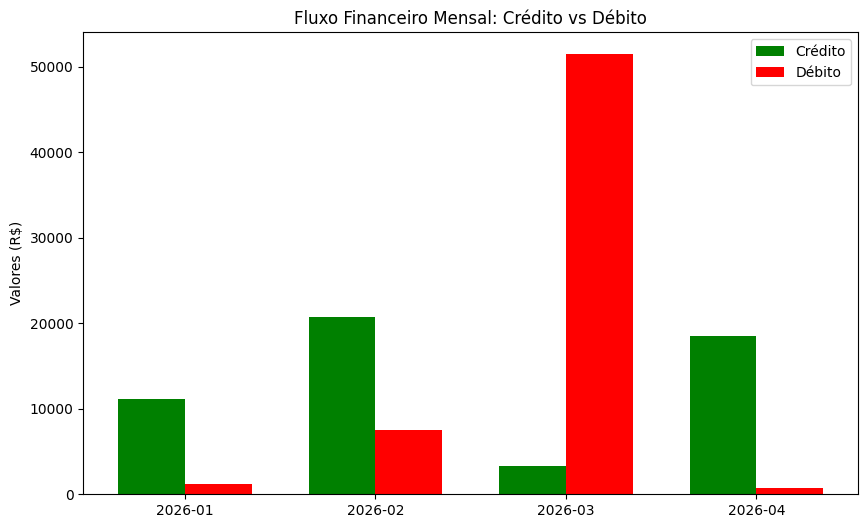

In [111]:
def executar_projeto():
    print("Iniciando processamento ClearBank...\n")

    # 1. Geração de dados (se necessário, o próprio método verifica se já existe)
    gerar_dados()

    # 2. 	Lê o CSV e retorna a lista de transações brutas / Valida uma única linha e retorna o registro limpo
    dados_limpos, qtdValidos, qtdinvalidos = ler_transacoes()

    # 3. Agrupa os dados e calcula as métricas
    if dados_limpos:
        relatorio = gerar_relatorio(dados_limpos, qtdValidos, qtdinvalidos)

        # 4. Formata e imprime os resultados no terminal
        exibir_relatorio(relatorio)

        # 5. Salva o resultado no arquivo relatorio.json
        salvar_json(relatorio)

        # 6. Geração de gráfico
        gerar_grafico(relatorio)
    else:
        print("Nenhum dado válido para processar. Verifique o arquivo CSV.")

executar_projeto()